# SVM Implementation

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

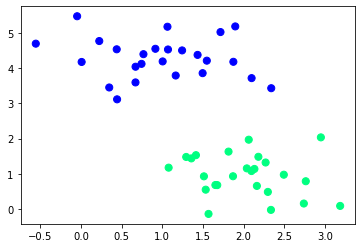

In [27]:
from sklearn.datasets import make_blobs

X,y=make_blobs(n_samples=50,centers=2,random_state=0,cluster_std=0.60)
plt.scatter(X[:,0],X[:,1],c=y,s=50,cmap='winter');

In [28]:
from sklearn.svm import SVC
model=SVC(kernel='linear',C=1)
model.fit(X,y)

SVC(C=1, kernel='linear')

In [29]:
def plot_svc_decision_function(model,ax=None,plot_support=True):
    
    # model → trained SVM model
    # ax → matplotlib axes
    # plot_support=True → whether to draw support vectors 
    
    if ax is None:
        ax=plt.gca() # Get current axis
    
    # These limits will be used to create a grid over the whole graph.
    xlim=ax.get_xlim()
    ylim=ax.get_ylim()
    
    # Create many x and y values
    x=np.linspace(xlim[0],xlim[1],30)
    y=np.linspace(ylim[0],ylim[1],30)
    
    # Create a grid of all x,y points
    Y,X=np.meshgrid(y,x)
    
    # Convert Grid Into Coordinates
    xy=np.vstack([X.ravel(),Y.ravel()]).T
    
    # The SVM evaluates every grid point.
    P=model.decision_function(xy).reshape(X.shape)
    
    # Draw the contour lines
    ax.contour(X,Y,P,colors='k',
              levels=[-1,0,1],alpha=0.5,
              linestyles=['--','-','--'])
    
    # Plot Support Vectors 
    if plot_support: # Only do this if user wants them.
        ax.scatter(model.support_vectors_[:,0],
                   model.support_vectors_[:,1],
                   s=300,linewidth=1,facecolor='None')
    # Restore Original Limits
    # Contour plotting sometimes changes axis limits to these lines restore the limits
    
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

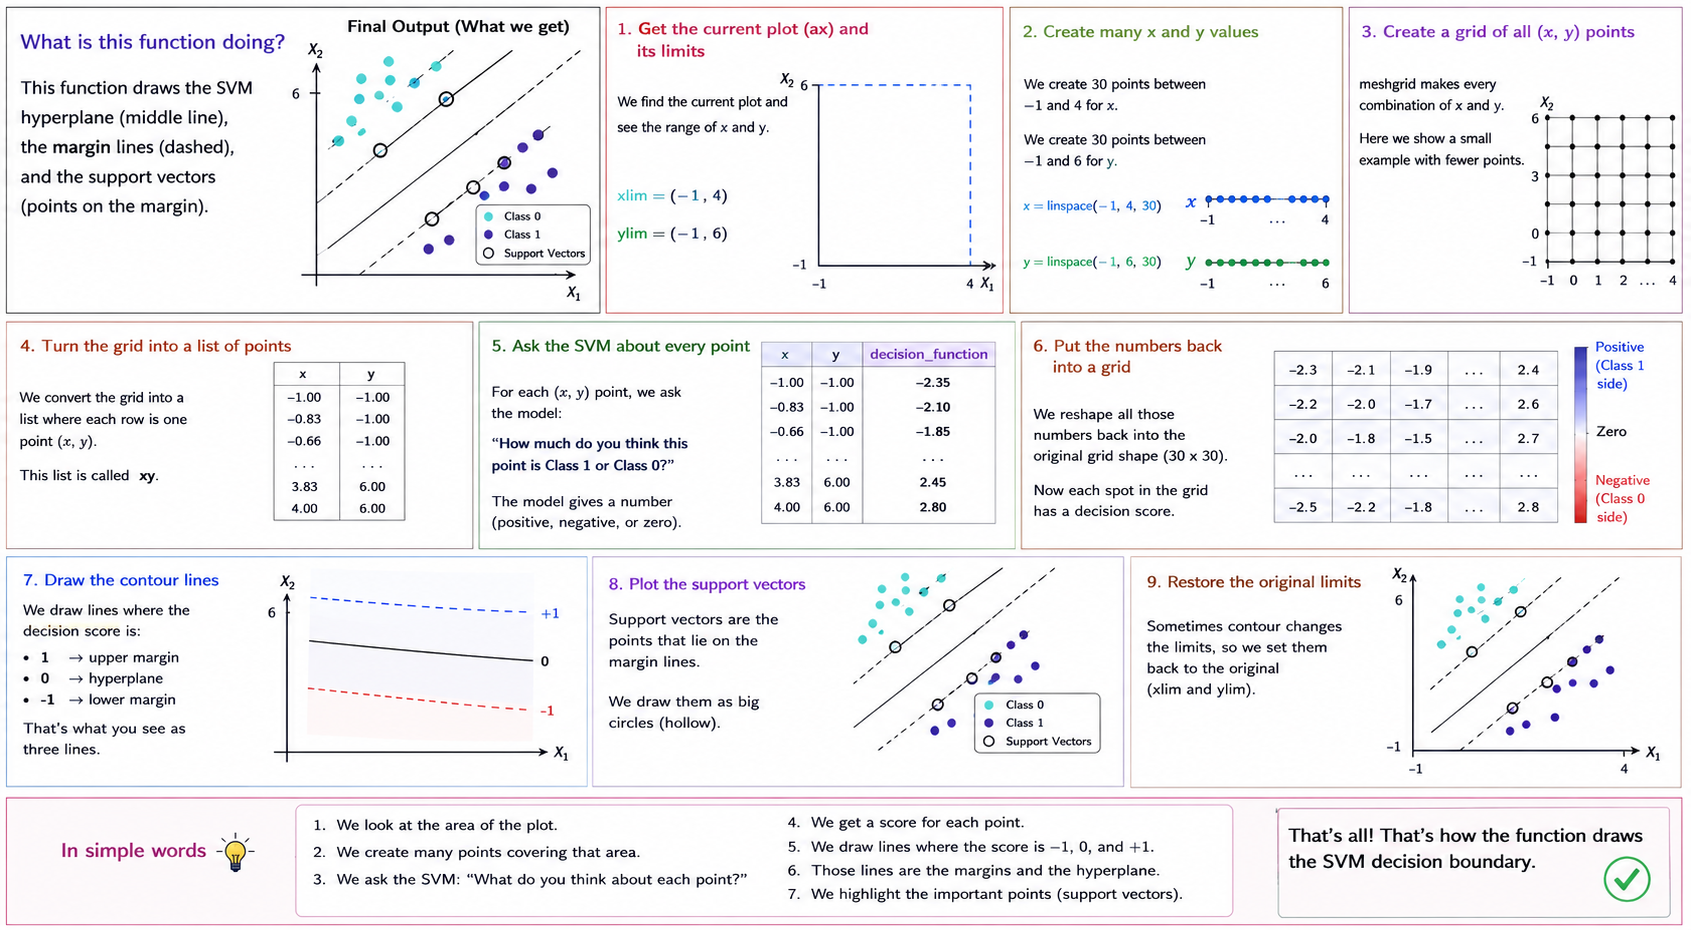

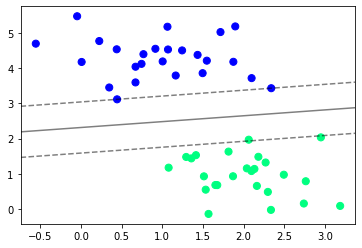

In [30]:
plt.scatter(X[:,0],X[:,1],c=y,s=50,cmap='winter')
plot_svc_decision_function(model);

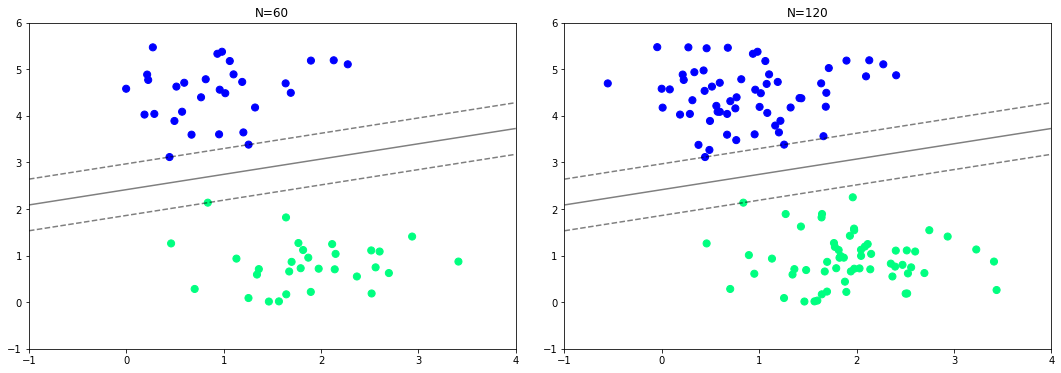

In [31]:
def plot_svm(N=10,ax=None):
    
    X,y=make_blobs(n_samples=200,centers=2,random_state=0,cluster_std=0.60)
    
    X=X[:N]
    y=y[:N]
    
    model=SVC(kernel='linear',C=1E10)
    model.fit(X,y)
    
    # ax=ax or plt.gca()

    # It means:
    # if ax is None:
    #     ax = plt.gca()

    # Suppose you call: plot_svm(60) -> No axis was provided, so it uses the current graph.
    # But if you call: plot_svm(60, ax[0]) -> then it uses the first subplot.
    ax=ax or plt.gca()
    
    ax.scatter(X[:,0],X[:,1],c=y,s=50,cmap='winter')
    
    # c=y : colors the classes differently. 
    # s=50 : controls the size of the dots (markers) in the scatter plot.

    # Without these below two lines, matplotlib might zoom differently for each graph.
    ax.set_xlim(-1,4)
    ax.set_ylim(-1,6)
    
    plot_svc_decision_function(model,ax)
    
fig,ax=plt.subplots(1,2,figsize=(16,6)) # This creates,One row, two columns. So that ax[0] is left graph and ax[1] is right graph
fig.subplots_adjust(left=0.0625,right=0.95,wspace=0.1) # Adjust spacing

for axi,N in zip(ax,[60,120]): # It creates (ax[0],60), (ax[1],120)
    plot_svm(N,axi) # Plots first N points on the axis of the graph
    axi.set_title('N={0} '.format(N))

Increasing the number of training points does not necessarily change the boundary because SVM depends mainly on support vectors.

# SVM with Almost Linearly seperable data

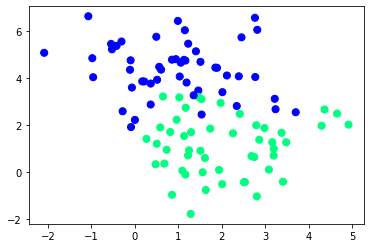

In [32]:
X,y=make_blobs(n_samples=100,centers=2,random_state=0,cluster_std=1.2)
plt.scatter(X[:,0],X[:,1],c=y,s=50,cmap='winter');

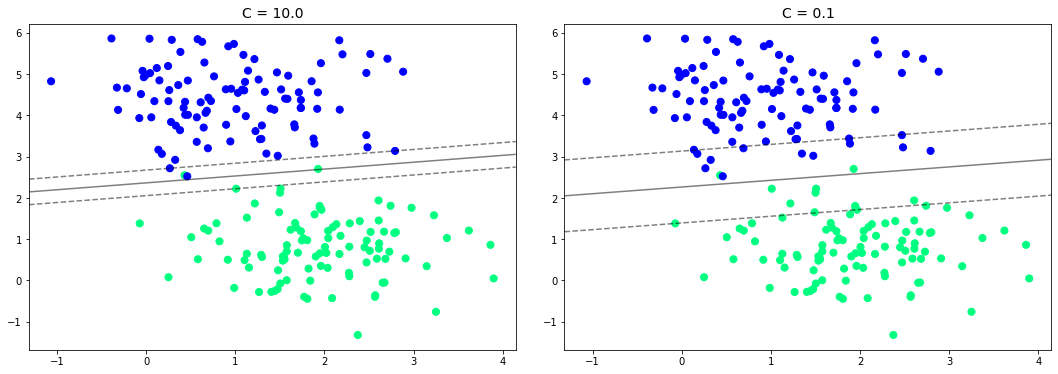

In [33]:
X,y=make_blobs(n_samples=200,centers=2,random_state=0,cluster_std=0.8)
    
fig,ax=plt.subplots(1,2,figsize=(16,6))
fig.subplots_adjust(left=0.0625,right=0.95,wspace=0.1)

for axi,C in zip(ax,[10.0,0.1]):
    model=SVC(kernel='linear',C=C).fit(X,y)
    axi.scatter(X[:,0],X[:,1],c=y,s=50,cmap='winter')
    plot_svc_decision_function(model,axi)
    axi.scatter(model.support_vectors_[:,0],
               model.support_vectors_[:,1],
               s=300,linewidth=1,facecolors='None')
    axi.set_title('C = {0:.1f}'.format(C),size=14)